In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import koreanize_matplotlib

warnings.filterwarnings('ignore')

In [26]:
d1 = pd.read_csv('./subway.csv')

d1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   역번호      10000 non-null  int64 
 1   호선       10000 non-null  int64 
 2   승하차구분    10000 non-null  object
 3   5시_승객수   10000 non-null  int64 
 4   6시_승객수   10000 non-null  int64 
 5   7시_승객수   10000 non-null  int64 
 6   8시_승객수   10000 non-null  int64 
 7   9시_승객수   10000 non-null  int64 
 8   10시_승객수  10000 non-null  int64 
 9   11시_승객수  10000 non-null  int64 
 10  12시_승객수  10000 non-null  int64 
 11  13시_승객수  10000 non-null  int64 
 12  14시_승객수  10000 non-null  int64 
 13  15시_승객수  10000 non-null  int64 
 14  16시_승객수  10000 non-null  int64 
 15  17시_승객수  10000 non-null  int64 
 16  18시_승객수  10000 non-null  int64 
 17  19시_승객수  10000 non-null  int64 
 18  20시_승객수  10000 non-null  int64 
 19  21시_승객수  10000 non-null  int64 
 20  일자       10000 non-null  object
dtypes: int64(19), object(2)
memory usage

In [27]:
d2 = pd.read_csv('./wether.csv')

d2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   일자      10000 non-null  object 
 1   시간      10000 non-null  int64  
 2   역번호     10000 non-null  int64  
 3   역이름     10000 non-null  object 
 4   지역      10000 non-null  object 
 5   역_lat   10000 non-null  float64
 6   역_lon   10000 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 547.0+ KB


In [28]:
d3 = pd.read_csv('./air.csv')

d3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   일자       20000 non-null  object 
 1   관측소이름    20000 non-null  object 
 2   관측소_lat  20000 non-null  float64
 3   관측소_lon  20000 non-null  float64
 4   관측소_기온   20000 non-null  float64
 5   관측소_습도   20000 non-null  float64
dtypes: float64(4), object(2)
memory usage: 937.6+ KB


In [29]:
cg = d1.columns[4:-1]

dt1 = d1.groupby(['일자', '역번호'])[cg].sum().reset_index()

In [30]:
dt1 = dt1.melt(id_vars=['일자', '역번호'], var_name='시간', value_name='count')

dt1['시간'] = dt1['시간'].str.replace('시_승객수', '').astype('int64')

dt1.head()

,일자,역번호,시간,count
0,2025-09-01,1,6,16701
1,2025-09-01,2,6,16100
2,2025-09-01,3,6,15293
3,2025-09-01,4,6,16607
4,2025-09-02,1,6,16804


In [31]:
len(dt1)

448

In [32]:
d2.head()

,일자,시간,역번호,역이름,지역,역_lat,역_lon
0,2025-09-01,0,1,서울역,서울,37.56,126.97
1,2025-09-01,0,3,대구역,대구,35.87,128.60
2,2025-09-01,0,4,광주역,광주,35.15,126.85
3,2025-09-01,0,4,광주역,광주,35.15,126.85
4,2025-09-01,0,2,부산역,부산,35.17,129.07


In [33]:
#역별로 위경도가 동일하다는 걸 놓침
tmp = d2.groupby('지역')['역_lat', '역_lon'].mean()

tmp

,역_lat,역_lon
지역,,
광주,35.15,126.85
대구,35.87,128.60
부산,35.17,129.07
서울,37.56,126.97


In [34]:
d3.head()

,일자,관측소이름,관측소_lat,관측소_lon,관측소_기온,관측소_습도
0,2025-09-01,대구관측소,35.8723,128.6042,24.40,50.72
1,2025-09-01,부산관측소,35.1723,129.0723,18.88,53.27
2,2025-09-01,서울관측소,37.5623,126.9723,20.51,87.82
3,2025-09-01,광주관측소,35.1534,126.8525,16.07,46.86
4,2025-09-01,광주관측소,35.1534,126.8525,22.00,41.50


In [35]:
cond1 = d3['관측소이름'].str[:2] == '광주'
cond2 = d3['관측소이름'].str[:2] == '대구'
cond3 = d3['관측소이름'].str[:2] == '부산'

d3['s_lat'] = np.where(cond1, 35.15, 
                        np.where(cond2, 35.87, 
                                np.where(cond3, 35.17, 37.56)))

d3['s_lon'] = np.where(cond1, 126.85, 
                        np.where(cond2, 128.60, 
                                np.where(cond3, 129.07, 126.97)))

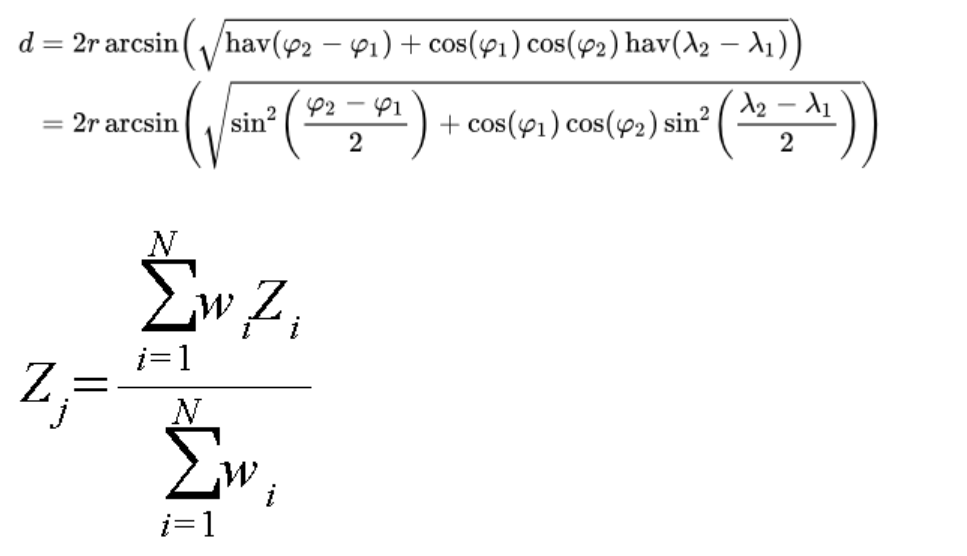





In [36]:
def dist(lat1, lon1, lat2, lon2):
    R = 6371
#     lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2]) #라디안 변환
    sin1 = np.sin((lat2-lat1)/2)**2
    cos1 = np.cos(lat1)
    cos2 = np.cos(lat2)
    sin2 = np.sin((lon2-lon1)/2)**2
    mid = np.sqrt(sin1+cos1*cos2*sin2)
    d = 2*R*np.arcsin(mid)
    return d


dist(35.15, 126.85, 35.1534, 126.8525)

25.365205181388234

In [37]:
d3.head()

,일자,관측소이름,관측소_lat,관측소_lon,관측소_기온,관측소_습도,s_lat,s_lon
0,2025-09-01,대구관측소,35.8723,128.6042,24.40,50.72,35.87,128.60
1,2025-09-01,부산관측소,35.1723,129.0723,18.88,53.27,35.17,129.07
2,2025-09-01,서울관측소,37.5623,126.9723,20.51,87.82,37.56,126.97
3,2025-09-01,광주관측소,35.1534,126.8525,16.07,46.86,35.15,126.85
4,2025-09-01,광주관측소,35.1534,126.8525,22.00,41.50,35.15,126.85


In [38]:
d3['dist'] = d3.apply(lambda row: dist(row['s_lat'], row['s_lon'], row['관측소_lat'], row['관측소_lon']), axis=1)

d3.head()

,일자,관측소이름,관측소_lat,관측소_lon,관측소_기온,관측소_습도,s_lat,s_lon,dist
0,2025-09-01,대구관측소,35.8723,128.6042,24.40,50.72,35.87,128.60,16.156597
1,2025-09-01,부산관측소,35.1723,129.0723,18.88,53.27,35.17,129.07,18.927208
2,2025-09-01,서울관측소,37.5623,126.9723,20.51,87.82,37.56,126.97,20.624677
3,2025-09-01,광주관측소,35.1534,126.8525,16.07,46.86,35.15,126.85,25.365205
4,2025-09-01,광주관측소,35.1534,126.8525,22.00,41.50,35.15,126.85,25.365205


In [39]:
def ch_z(d, z):
    w = 1/d
    total_w = w.sum()
    up = total_w*z
    rs = up/total_w
    return rs

c_cols = ['관측소_기온', '관측소_습도']

for c in c_cols:
    new_c = 'n' + c.replace('관측소_', '')
    d3[new_c] = ch_z(d3['dist'], d3[c])

In [40]:
d3.head()

,일자,관측소이름,관측소_lat,관측소_lon,관측소_기온,관측소_습도,s_lat,s_lon,dist,n기온,n습도
0,2025-09-01,대구관측소,35.8723,128.6042,24.40,50.72,35.87,128.60,16.156597,24.40,50.72
1,2025-09-01,부산관측소,35.1723,129.0723,18.88,53.27,35.17,129.07,18.927208,18.88,53.27
2,2025-09-01,서울관측소,37.5623,126.9723,20.51,87.82,37.56,126.97,20.624677,20.51,87.82
3,2025-09-01,광주관측소,35.1534,126.8525,16.07,46.86,35.15,126.85,25.365205,16.07,46.86
4,2025-09-01,광주관측소,35.1534,126.8525,22.00,41.50,35.15,126.85,25.365205,22.00,41.50


In [41]:
d3['지역'] = d3['관측소이름'].str.replace('관측소', '')

In [42]:
mg = pd.merge(d2, d3[['일자', '지역', 'n기온', 'n습도']], on=['일자', '지역'], how='left')

In [43]:
mg.head()

,일자,시간,역번호,역이름,지역,역_lat,역_lon,n기온,n습도
0,2025-09-01,0,1,서울역,서울,37.56,126.97,20.51,87.82
1,2025-09-01,0,1,서울역,서울,37.56,126.97,26.94,72.71
2,2025-09-01,0,1,서울역,서울,37.56,126.97,13.87,87.25
3,2025-09-01,0,1,서울역,서울,37.56,126.97,17.71,42.44
4,2025-09-01,0,1,서울역,서울,37.56,126.97,19.60,48.03


In [44]:
train = pd.merge(mg, dt1, on=['일자', '시간', '역번호'], how='inner')

train.head()

,일자,시간,역번호,역이름,지역,역_lat,역_lon,n기온,n습도,count
0,2025-09-01,6,1,서울역,서울,37.56,126.97,20.51,87.82,16701
1,2025-09-01,6,1,서울역,서울,37.56,126.97,26.94,72.71,16701
2,2025-09-01,6,1,서울역,서울,37.56,126.97,13.87,87.25,16701
3,2025-09-01,6,1,서울역,서울,37.56,126.97,17.71,42.44,16701
4,2025-09-01,6,1,서울역,서울,37.56,126.97,19.60,48.03,16701


In [45]:
#어휴 망했다...

n_cols = train.select_dtypes('number').columns
c_cols = train.select_dtypes('O').columns[1:]

print("<<통계량>>")
display(train[n_cols].describe().T)
display(train[c_cols].describe().T)

<<통계량>>


,count,mean,std,min,25%,50%,75%,max
시간,40626.0,13.530301,4.595428,6.00,10.00,14.00,17.00,21.00
역번호,40626.0,2.514498,1.069590,1.00,2.00,2.00,3.00,4.00
역_lat,40626.0,35.822551,0.930016,35.15,35.17,35.17,35.87,37.56
역_lon,40626.0,127.990661,0.992141,126.85,126.97,128.60,129.07,129.07
n기온,40626.0,19.970051,5.244545,4.83,16.56,19.91,23.33,32.61
n습도,40626.0,65.308147,14.118124,40.53,53.61,66.68,77.16,89.66
count,40626.0,29573.815094,8339.846369,14569.00,22566.00,29675.00,36543.00,46211.00


,count,unique,top,freq
역이름,40626,4,부산역,12829
지역,40626,4,부산,12829


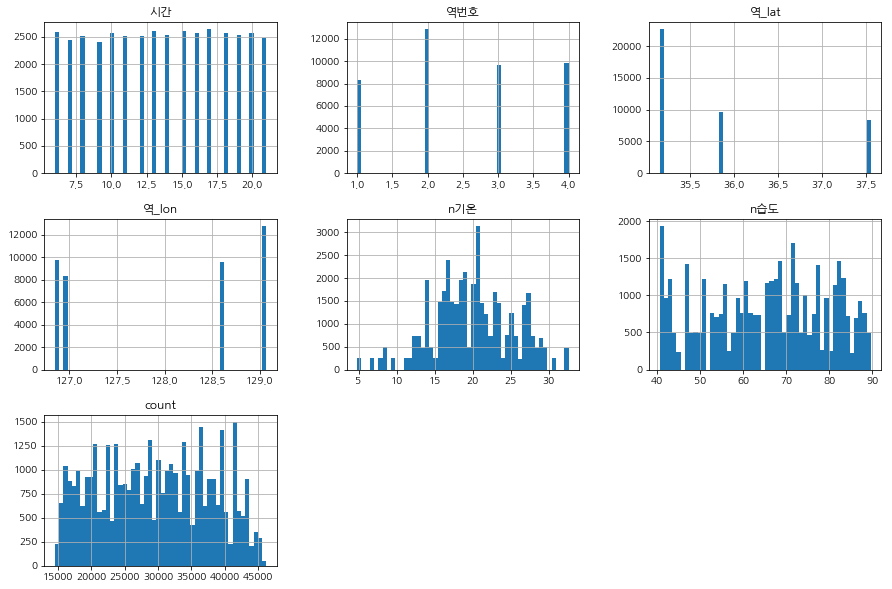

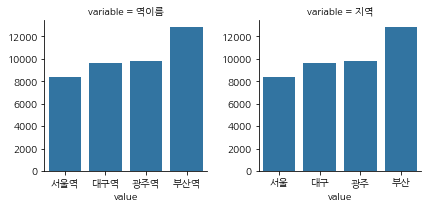

In [46]:
train[n_cols].hist(bins=50, figsize=(15, 10))
plt.show()

mt = train[c_cols].melt()
g = sns.FacetGrid(mt, col='variable', sharex=False, sharey=False, col_wrap=4)
g.map(sns.countplot, 'value')
plt.show()

In [59]:
cg = ['시간', '역번호']

train[cg] = train[cg].astype('O')

In [60]:
size = int(len(train)*0.8)
train, test = train[:size], train.iloc[size:]

print(train.shape, test.shape)

(26000, 10) (6500, 10)


In [61]:
train_x, train_y = train[['시간', '역번호', '역이름', 'n기온', 'n습도']], train['count']
test_x, test_y = test[['시간', '역번호', '역이름', 'n기온', 'n습도']], test['count']

In [65]:
n_cols = train_x.select_dtypes('number').columns
c_cols = train_x.select_dtypes('O').columns

from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

pre = make_column_transformer(
    (Pipeline([('one', OneHotEncoder(handle_unknown='ignore'))]), c_cols), 
    remainder='passthrough'
)

rf = Pipeline([
    ('pre', pre), 
    ('cl', RandomForestRegressor(random_state=42))
])

rf.fit(train_x, train_y)

rs = pd.DataFrame(columns=['data', 'r2', 'rmse'])

d_list = [('train', train_x, train_y), ('test', test_x, test_y)]

for n, x, y in d_list:
    pred = rf.predict(x)
    r2 = r2_score(y, pred)
    rmse = np.sqrt(mean_squared_error(y, pred))
    rs.loc[len(rs)] = [n, r2, rmse]
display(rs)

,data,r2,rmse
0,train,1.000000,0.141214
1,test,0.959543,1605.219002


In [71]:
1605.219002/(test_y.max() - test_y.min())*100

5.33224489104438

랜덤포레스트 학습 결과 rmse에서 과적합이 발생한 것 같지만 종속변수 범위를 보았을 때, 범위 대비 약 5.3%의 표준오차를 가지며,  
r2 설명력이 거의 1에 가까운 값을 가지므로 우수한 모델이라고 할 수 있다.   

r2 설명력: ssr/sst로 종속변수의 분산을 약 96% 설명  
rmse: mse의 제곱근으로 종속변수와 단위가 같아 표준오차 추정 가능

//끝.